# Standard Variational Autoencoder (VAE)

| Tutorial status | Details |
|---|---|
| **Course role** | Core teaching anchor for amortized variational inference |
| **Expected runtime** | Under 2 minutes for a full run |
| **Hardware** | CPU is sufficient; CUDA is optional |
| **External data** | Synthetic data generated in the notebook |
| **Validation** | Fully executable teaching workflow |


In this notebook, we implement a standard Variational Autoencoder (VAE) on simple data (Gaussian mixture or MNIST). This serves as a foundation for understanding **Sequential VAEs** like LFADS, which we'll study next.

## What is a VAE?

A VAE is a generative model that learns to:
1. **Encode** high-dimensional data into a low-dimensional latent space
2. **Decode** samples from the latent space back to the data space
3. Balance reconstruction accuracy with a regularization penalty (KL divergence)

**Key insight**: Instead of learning a deterministic mapping, VAEs learn **distributions** over latent variables, enabling both inference and generation.

**References**:
- Kingma & Welling (2013). "Auto-Encoding Variational Bayes" https://arxiv.org/abs/1312.6114
- PyTorch Official VAE Example: https://github.com/pytorch/examples/tree/main/vae


## Part 0: Setup and Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.distributions import Normal

import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange, tqdm

# Set random seed for reproducibility
torch.manual_seed(0)
np.random.seed(0)

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Part 1: Generate or Load Data

We'll use a simple 2D Gaussian mixture model for visualization and interpretability.

Data shape: torch.Size([4998, 2])


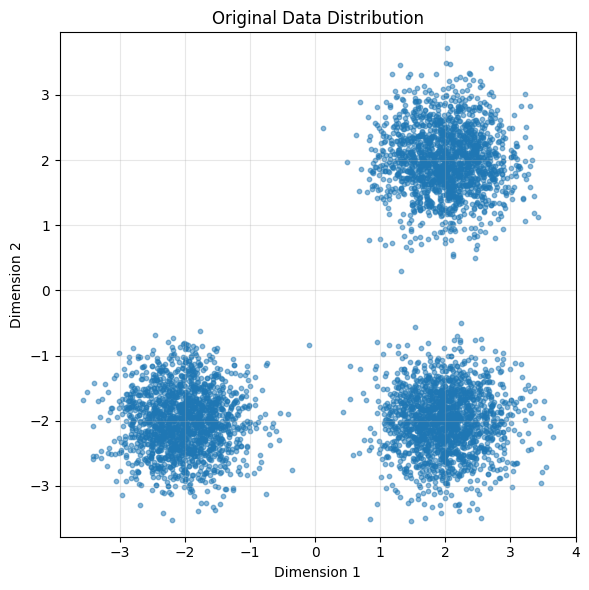

In [2]:
# Generate 2D Gaussian mixture data
def generate_gaussian_mixture(n_samples=5000, n_components=3):
    """Generate data from a Gaussian mixture model."""
    np.random.seed(0)
    
    # Define component means
    means = np.array([
        [-2, -2],
        [2, 2],
        [2, -2]
    ])[:n_components]
    
    # Generate data
    samples = []
    for i in range(n_components):
        n = n_samples // n_components
        component_samples = np.random.randn(n, 2) * 0.5 + means[i]
        samples.append(component_samples)
    
    data = np.vstack(samples)
    np.random.shuffle(data)
    return torch.FloatTensor(data)

# Generate data
data = generate_gaussian_mixture(n_samples=5000, n_components=3)
print(f"Data shape: {data.shape}")

# Create DataLoader
dataset = TensorDataset(data)
train_loader = DataLoader(dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(dataset, batch_size=128, shuffle=False)

# Plot original data
plt.figure(figsize=(6, 6))
plt.scatter(data[:, 0], data[:, 1], alpha=0.5, s=10)
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.title('Original Data Distribution')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()

## Part 2: VAE Model Architecture

### Part 2a: Encoder

The encoder maps data $x$ to a distribution over latent variables:
$$q_\phi(z|x) = \mathcal{N}(\mu_\phi(x), \sigma_\phi^2(x))$$

In [3]:
class Encoder(nn.Module):
    """Encoder: maps data to latent variable distribution.
    
    Maps input x to mean and log-variance of q(z|x).
    """
    def __init__(self, input_dim=2, hidden_dim=32, latent_dim=2):
        super(Encoder, self).__init__()
        
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        
        # Output: mean and log-variance of latent distribution
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
    
    def forward(self, x):
        """Forward pass.
        
        Args:
            x: input data (batch_size, input_dim)
        
        Returns:
            mu: mean of q(z|x) (batch_size, latent_dim)
            logvar: log-variance of q(z|x) (batch_size, latent_dim)
        """
        h = F.relu(self.fc1(x))
        h = F.relu(self.fc2(h))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

### Part 2b: Reparameterization Trick

To backpropagate through sampling, we use the **reparameterization trick**:
$$z = \mu + \epsilon \odot \sigma, \quad \epsilon \sim \mathcal{N}(0, I)$$

This allows gradients to flow through the stochastic sampling process.

In [4]:
def reparameterize(mu, logvar):
    """Reparameterization trick: sample z ~ q(z|x).
    
    Args:
        mu: mean of q(z|x)
        logvar: log-variance of q(z|x)
    
    Returns:
        z: sample from q(z|x)
    """
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    z = mu + eps * std
    return z

### Part 2c: Decoder

The decoder maps latent variables back to data space:
$$p_\theta(x|z)$$

In [5]:
class Decoder(nn.Module):
    """Decoder: maps latent variables to data.
    
    Maps latent z to reconstructed data x_hat.
    """
    def __init__(self, latent_dim=2, hidden_dim=32, output_dim=2):
        super(Decoder, self).__init__()
        
        self.fc1 = nn.Linear(latent_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, z):
        """Forward pass.
        
        Args:
            z: latent variables (batch_size, latent_dim)
        
        Returns:
            x_recon: reconstructed data (batch_size, output_dim)
        """
        h = F.relu(self.fc1(z))
        h = F.relu(self.fc2(h))
        x_recon = self.fc_out(h)
        return x_recon

### Part 2d: Complete VAE

Combine encoder, reparameterization, and decoder into a single VAE module.

In [6]:
class VAE(nn.Module):
    """Variational Autoencoder."""
    
    def __init__(self, input_dim=2, hidden_dim=32, latent_dim=2):
        super(VAE, self).__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, input_dim)
        self.latent_dim = latent_dim
    
    def forward(self, x):
        """Forward pass through VAE.
        
        Args:
            x: input data (batch_size, input_dim)
        
        Returns:
            x_recon: reconstructed data
            mu: mean of q(z|x)
            logvar: log-variance of q(z|x)
            z: sampled latent variables
        """
        # Encode
        mu, logvar = self.encoder(x)
        
        # Reparameterize
        z = reparameterize(mu, logvar)
        
        # Decode
        x_recon = self.decoder(z)
        
        return x_recon, mu, logvar, z

### Part 2e: Architecture of the Standard VAE

**Figure 1 | Information flow and learning objective.** The inference network maps each observation to the parameters of a diagonal Gaussian posterior. Reparameterized samples pass through the generative network to produce reconstructions. Training balances reconstruction fidelity against the divergence between the approximate posterior and the unit-Gaussian prior.


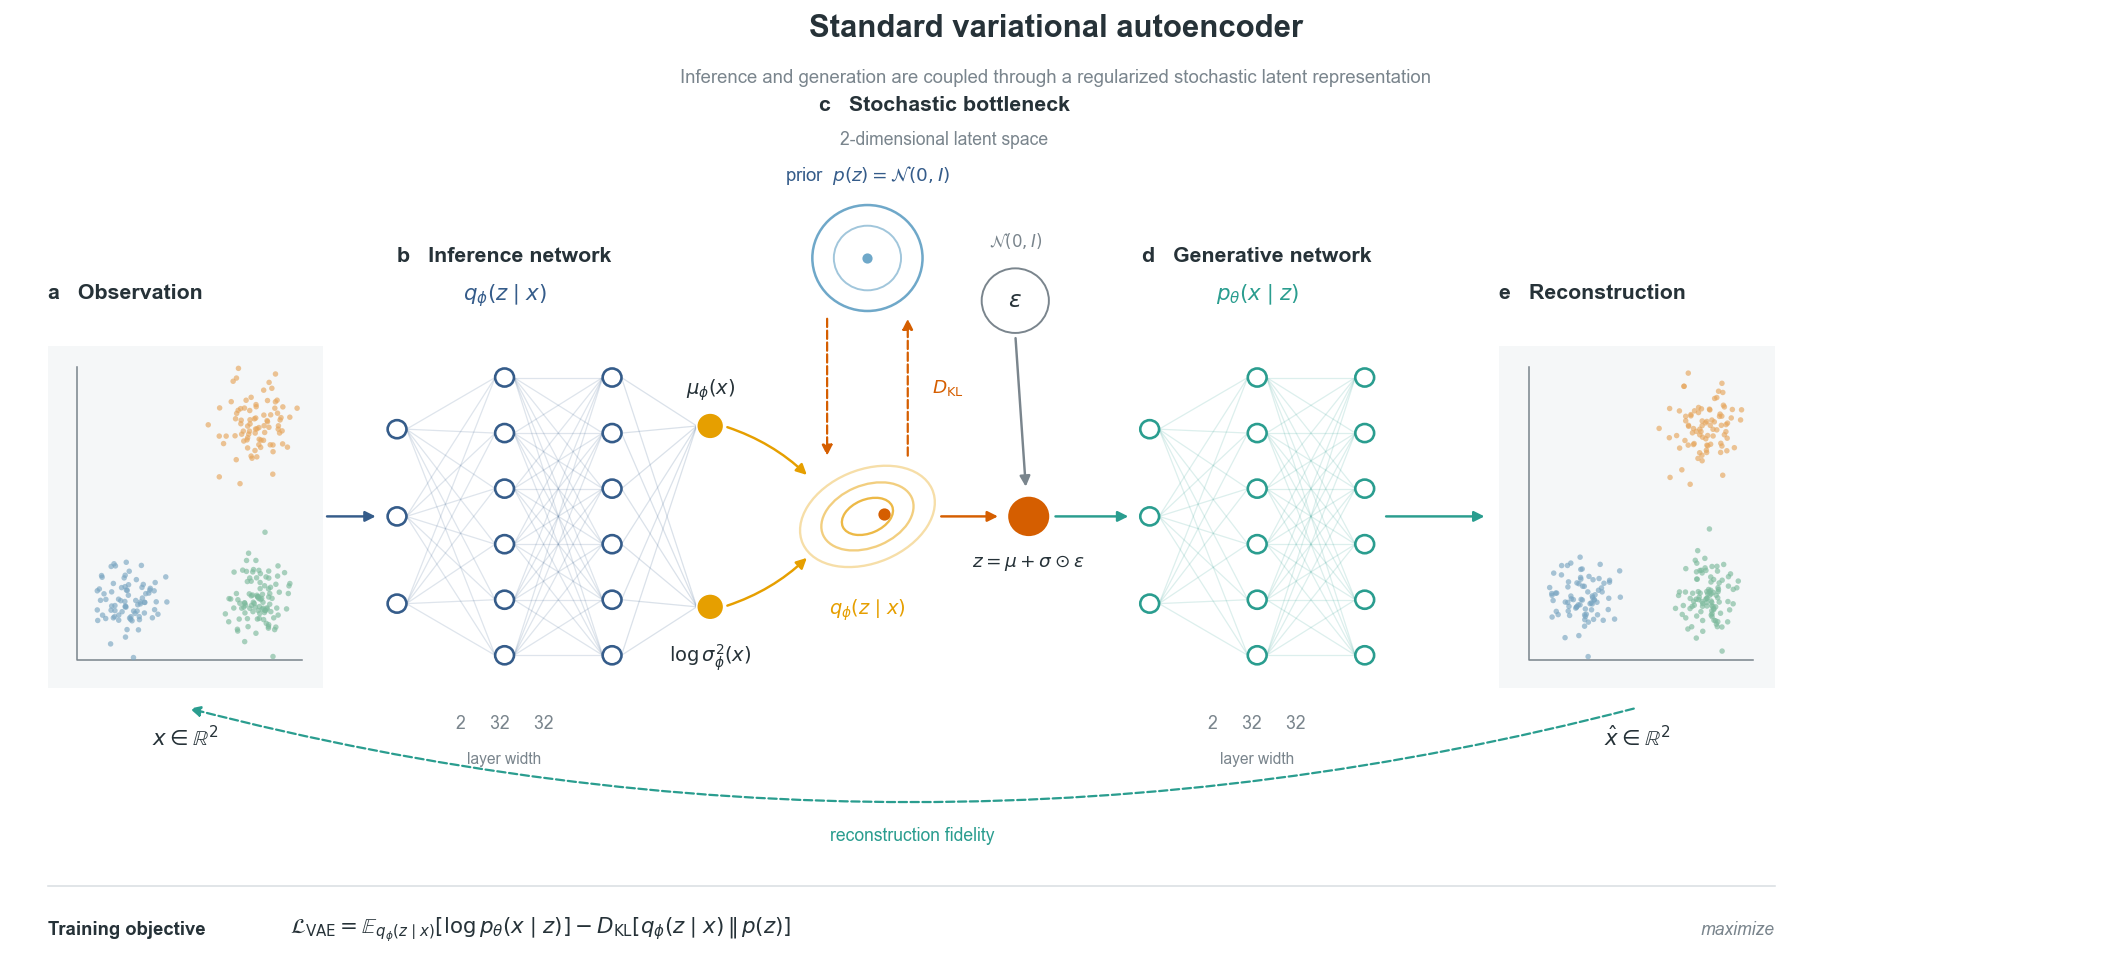

In [7]:
# Draw the VAE architecture used in this notebook
from matplotlib.patches import Circle, Ellipse, FancyArrowPatch, Rectangle
from matplotlib.lines import Line2D


with plt.rc_context({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 10,
    "axes.linewidth": 0.8,
}):
    fig = plt.figure(figsize=(15.5, 7.2), dpi=140, facecolor="white")
    ax = fig.add_axes([0.02, 0.04, 0.96, 0.91])
    ax.set_xlim(0, 15.5)
    ax.set_ylim(0, 7.1)
    ax.axis("off")

    # Colorblind-safe, print-friendly palette.
    navy = "#355C8A"
    sky = "#6FA8C9"
    teal = "#2A9D8F"
    orange = "#E69F00"
    vermillion = "#D55E00"
    charcoal = "#263238"
    midgray = "#7A858D"
    lightgray = "#D9DEE2"
    palegray = "#F5F7F8"
    cluster_colors = ["#7AA6C2", "#E6A65D", "#7DBA9D"]


    def add_arrow(start, end, color=charcoal, lw=1.25, style="-", curve=0.0, zorder=2):
        arrow = FancyArrowPatch(
            start,
            end,
            arrowstyle="-|>",
            mutation_scale=11,
            linewidth=lw,
            linestyle=style,
            color=color,
            connectionstyle=f"arc3,rad={curve}",
            shrinkA=2,
            shrinkB=2,
            zorder=zorder,
        )
        ax.add_patch(arrow)
        return arrow


    def draw_layer(x, n_nodes, center_y, span, color, radius=0.07):
        ys = np.linspace(center_y - span / 2, center_y + span / 2, n_nodes)
        for y in ys:
            ax.add_patch(Circle((x, y), radius, facecolor="white", edgecolor=color, linewidth=1.35, zorder=4))
        return ys


    def connect_layers(x1, ys1, x2, ys2, color):
        for y1 in ys1:
            for y2 in ys2:
                ax.plot([x1 + 0.07, x2 - 0.07], [y1, y2], color=color, alpha=0.16, linewidth=0.65, zorder=1)


    def mini_axes(x0, y0, width, height, title, symbol):
        ax.add_patch(Rectangle((x0, y0), width, height, facecolor=palegray, edgecolor="none", zorder=0))
        ax.plot([x0 + 0.22, x0 + 0.22, x0 + width - 0.16],
                [y0 + height - 0.16, y0 + 0.22, y0 + 0.22],
                color=midgray, linewidth=0.8, zorder=2)
        ax.text(x0, y0 + height + 0.34, title, ha="left", va="bottom", fontsize=11, fontweight="bold", color=charcoal)
        ax.text(x0 + width / 2, y0 - 0.28, symbol, ha="center", va="top", fontsize=11, color=charcoal)


    # Panel a: observed data distribution.
    input_x, input_y, panel_w, panel_h = 0.25, 2.15, 2.05, 2.65
    mini_axes(input_x, input_y, panel_w, panel_h, "a   Observation", r"$x\in\mathbb{R}^{2}$")

    points = data.detach().cpu().numpy()
    rng = np.random.default_rng(12)
    subset = points[rng.choice(len(points), size=260, replace=False)]
    centers = np.array([[-2, -2], [2, 2], [2, -2]])
    labels = np.argmin(((subset[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2), axis=1)
    px = input_x + 0.30 + (subset[:, 0] + 3.2) / 6.4 * (panel_w - 0.50)
    py = input_y + 0.30 + (subset[:, 1] + 3.2) / 6.4 * (panel_h - 0.50)
    for cluster in range(3):
        mask = labels == cluster
        ax.scatter(px[mask], py[mask], s=8, color=cluster_colors[cluster], alpha=0.65, edgecolors="none", zorder=3)

    # Panel b: inference network with exact layer dimensions.
    enc_x = [2.85, 3.65, 4.45]
    enc_layers = [
        draw_layer(enc_x[0], 3, 3.48, 1.35, navy),
        draw_layer(enc_x[1], 6, 3.48, 2.15, navy),
        draw_layer(enc_x[2], 6, 3.48, 2.15, navy),
    ]
    connect_layers(enc_x[0], enc_layers[0], enc_x[1], enc_layers[1], navy)
    connect_layers(enc_x[1], enc_layers[1], enc_x[2], enc_layers[2], navy)
    add_arrow((input_x + panel_w, 3.48), (enc_x[0] - 0.13, 3.48), color=navy)

    mu_y, logvar_y = 4.18, 2.78
    ax.add_patch(Circle((5.18, mu_y), 0.10, facecolor=orange, edgecolor="white", linewidth=0.8, zorder=4))
    ax.add_patch(Circle((5.18, logvar_y), 0.10, facecolor=orange, edgecolor="white", linewidth=0.8, zorder=4))
    for y in enc_layers[-1]:
        ax.plot([enc_x[-1] + 0.07, 5.08], [y, mu_y], color=navy, alpha=0.18, linewidth=0.65)
        ax.plot([enc_x[-1] + 0.07, 5.08], [y, logvar_y], color=navy, alpha=0.18, linewidth=0.65)
    ax.text(5.18, mu_y + 0.25, r"$\mu_{\phi}(x)$", ha="center", fontsize=10, color=charcoal)
    ax.text(5.18, logvar_y - 0.27, r"$\log\sigma_{\phi}^{2}(x)$", ha="center", va="top", fontsize=10, color=charcoal)
    ax.text(3.65, 5.45, "b   Inference network", ha="center", fontsize=11, fontweight="bold", color=charcoal)
    ax.text(3.65, 5.16, r"$q_{\phi}(z\mid x)$", ha="center", fontsize=11, color=navy)
    ax.text(3.65, 1.84, "2     32     32", ha="center", fontsize=9, color=midgray)
    ax.text(3.65, 1.57, "layer width", ha="center", fontsize=8, color=midgray)

    # Panel c: approximate posterior, prior, and reparameterization.
    q_center = (6.35, 3.48)
    for width, height, alpha in [(1.05, 0.72, 0.34), (0.72, 0.48, 0.50), (0.40, 0.26, 0.72)]:
        ax.add_patch(Ellipse(q_center, width, height, angle=24, facecolor="none", edgecolor=orange, linewidth=1.2, alpha=alpha))
    ax.scatter([q_center[0] + 0.12], [q_center[1] + 0.02], s=28, color=vermillion, zorder=5)
    add_arrow((5.28, mu_y), (5.92, 3.78), color=orange, curve=-0.12)
    add_arrow((5.28, logvar_y), (5.92, 3.18), color=orange, curve=0.12)
    ax.text(6.35, 2.72, r"$q_{\phi}(z\mid x)$", ha="center", fontsize=10, color=orange, fontweight="bold")

    prior_center = (6.35, 5.48)
    ax.add_patch(Ellipse(prior_center, 0.82, 0.82, facecolor="none", edgecolor=sky, linewidth=1.3))
    ax.add_patch(Ellipse(prior_center, 0.50, 0.50, facecolor="none", edgecolor=sky, linewidth=1.0, alpha=0.65))
    ax.scatter([prior_center[0]], [prior_center[1]], s=18, color=sky, zorder=4)
    ax.text(6.35, 6.08, r"prior  $p(z)=\mathcal{N}(0,I)$", ha="center", fontsize=9.5, color=navy)
    add_arrow((6.05, 5.04), (6.05, 3.92), color=vermillion, style="--", lw=1.15)
    add_arrow((6.65, 3.92), (6.65, 5.04), color=vermillion, style="--", lw=1.15)
    ax.text(6.83, 4.48, r"$D_{\mathrm{KL}}$", ha="left", va="center", fontsize=9.5, color=vermillion)

    eps_center = (7.45, 5.15)
    ax.add_patch(Circle(eps_center, 0.25, facecolor="white", edgecolor=midgray, linewidth=1.0))
    ax.text(*eps_center, r"$\epsilon$", ha="center", va="center", fontsize=12, color=charcoal)
    ax.text(7.45, 5.57, r"$\mathcal{N}(0,I)$", ha="center", fontsize=8.5, color=midgray)

    z_center = (7.55, 3.48)
    ax.add_patch(Circle(z_center, 0.16, facecolor=vermillion, edgecolor="white", linewidth=1.0, zorder=5))
    ax.text(7.55, 3.09, r"$z=\mu+\sigma\odot\epsilon$", ha="center", fontsize=9.5, color=charcoal)
    add_arrow((6.87, 3.48), (7.35, 3.48), color=vermillion)
    add_arrow((7.45, 4.89), (7.53, 3.68), color=midgray)
    ax.text(6.92, 6.62, "c   Stochastic bottleneck", ha="center", fontsize=11, fontweight="bold", color=charcoal)
    ax.text(6.92, 6.36, "2-dimensional latent space", ha="center", fontsize=9, color=midgray)

    # Panel d: generative network.
    dec_x = [8.45, 9.25, 10.05]
    dec_layers = [
        draw_layer(dec_x[0], 3, 3.48, 1.35, teal),
        draw_layer(dec_x[1], 6, 3.48, 2.15, teal),
        draw_layer(dec_x[2], 6, 3.48, 2.15, teal),
    ]
    connect_layers(dec_x[0], dec_layers[0], dec_x[1], dec_layers[1], teal)
    connect_layers(dec_x[1], dec_layers[1], dec_x[2], dec_layers[2], teal)
    add_arrow((7.72, 3.48), (dec_x[0] - 0.13, 3.48), color=teal)
    ax.text(9.25, 5.45, "d   Generative network", ha="center", fontsize=11, fontweight="bold", color=charcoal)
    ax.text(9.25, 5.16, r"$p_{\theta}(x\mid z)$", ha="center", fontsize=11, color=teal)
    ax.text(9.25, 1.84, "2     32     32", ha="center", fontsize=9, color=midgray)
    ax.text(9.25, 1.57, "layer width", ha="center", fontsize=8, color=midgray)

    # Panel e: reconstructed distribution.
    output_x, output_y = 11.05, 2.15
    mini_axes(output_x, output_y, panel_w, panel_h, "e   Reconstruction", r"$\hat{x}\in\mathbb{R}^{2}$")
    add_arrow((dec_x[-1] + 0.13, 3.48), (output_x - 0.08, 3.48), color=teal)

    reconstructed = subset * 0.96 + rng.normal(0, 0.07, size=subset.shape)
    rpx = output_x + 0.30 + (reconstructed[:, 0] + 3.2) / 6.4 * (panel_w - 0.50)
    rpy = output_y + 0.30 + (reconstructed[:, 1] + 3.2) / 6.4 * (panel_h - 0.50)
    for cluster in range(3):
        mask = labels == cluster
        ax.scatter(rpx[mask], rpy[mask], s=8, color=cluster_colors[cluster], alpha=0.65, edgecolors="none", zorder=3)

    # Reconstruction comparison and objective strip.
    add_arrow((12.08, 2.00), (1.28, 2.00), color=teal, style="--", lw=1.15, curve=-0.13)
    ax.text(6.68, 0.97, "reconstruction fidelity", ha="center", fontsize=9, color=teal)

    ax.plot([0.25, 13.1], [0.62, 0.62], color=lightgray, linewidth=0.8)
    ax.text(0.25, 0.28, "Training objective", ha="left", va="center", fontsize=9.5, fontweight="bold", color=charcoal)
    ax.text(
        2.05,
        0.28,
        r"$\mathcal{L}_{\mathrm{VAE}}="
        r"\mathbb{E}_{q_{\phi}(z\mid x)}[\log p_{\theta}(x\mid z)]"
        r"-D_{\mathrm{KL}}[q_{\phi}(z\mid x)\,\|\,p(z)]$",
        ha="left",
        va="center",
        fontsize=11,
        color=charcoal,
    )
    ax.text(13.1, 0.28, "maximize", ha="right", va="center", fontsize=9, color=midgray, style="italic")

    fig.suptitle(
        "Standard variational autoencoder",
        x=0.5,
        y=0.985,
        fontsize=16,
        fontweight="bold",
        color=charcoal,
    )
    ax.text(7.75, 6.88, "Inference and generation are coupled through a regularized stochastic latent representation",
            ha="center", va="center", fontsize=9.5, color=midgray)

    plt.show()

## Part 3: ELBO Loss Function

The VAE is trained by maximizing the **Evidence Lower BOund (ELBO)**:

$$\mathcal{L}(\theta, \phi; x) = \underbrace{\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)]}_\text{Reconstruction} - \underbrace{D_{KL}(q_\phi(z|x) || p(z))}_\text{KL Regularization}$$

Where:
- **Reconstruction term**: How well can we reconstruct x from z?
- **KL term**: How close is the learned posterior to the prior p(z) = N(0, I)?

In [8]:
def vae_loss(x_recon, x, mu, logvar):
    """Compute VAE loss (negative ELBO).
    
    Args:
        x_recon: reconstructed data
        x: original data
        mu: mean of q(z|x)
        logvar: log-variance of q(z|x)
    
    Returns:
        loss: negative ELBO (scalar)
        recon_loss: reconstruction loss component
        kl_loss: KL divergence component
    """
    # Reconstruction loss: mean squared error
    recon_loss = F.mse_loss(x_recon, x, reduction='mean')
    
    # KL divergence: D_KL(q(z|x) || p(z)) where p(z) = N(0, I)
    # KL = -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    
    # Total loss
    loss = recon_loss + kl_loss
    
    return loss, recon_loss, kl_loss

## Part 4: Training Loop

In [9]:
# Initialize model
model = VAE(input_dim=2, hidden_dim=32, latent_dim=2).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training parameters
num_epochs = 50
train_losses = []
recon_losses = []
kl_losses = []

# Training loop
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    epoch_recon = 0
    epoch_kl = 0
    
    for batch_idx, (x,) in enumerate(train_loader):
        x = x.to(device)
        
        # Forward pass
        x_recon, mu, logvar, z = model(x)
        
        # Compute loss
        loss, recon, kl = vae_loss(x_recon, x, mu, logvar)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        epoch_recon += recon.item()
        epoch_kl += kl.item()
    
    # Average loss over epoch
    avg_loss = epoch_loss / len(train_loader)
    avg_recon = epoch_recon / len(train_loader)
    avg_kl = epoch_kl / len(train_loader)
    
    train_losses.append(avg_loss)
    recon_losses.append(avg_recon)
    kl_losses.append(avg_kl)
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}, Recon: {avg_recon:.4f}, KL: {avg_kl:.4f}')

print('\nTraining complete!')

Epoch 10/50 - Loss: 1.2157, Recon: 0.4162, KL: 0.7994
Epoch 20/50 - Loss: 1.1369, Recon: 0.3637, KL: 0.7732
Epoch 30/50 - Loss: 1.1137, Recon: 0.3626, KL: 0.7510
Epoch 40/50 - Loss: 1.0962, Recon: 0.3434, KL: 0.7528
Epoch 50/50 - Loss: 1.0751, Recon: 0.3395, KL: 0.7356

Training complete!


## Part 5: Analysis and Results

### Part 5a: Training curves

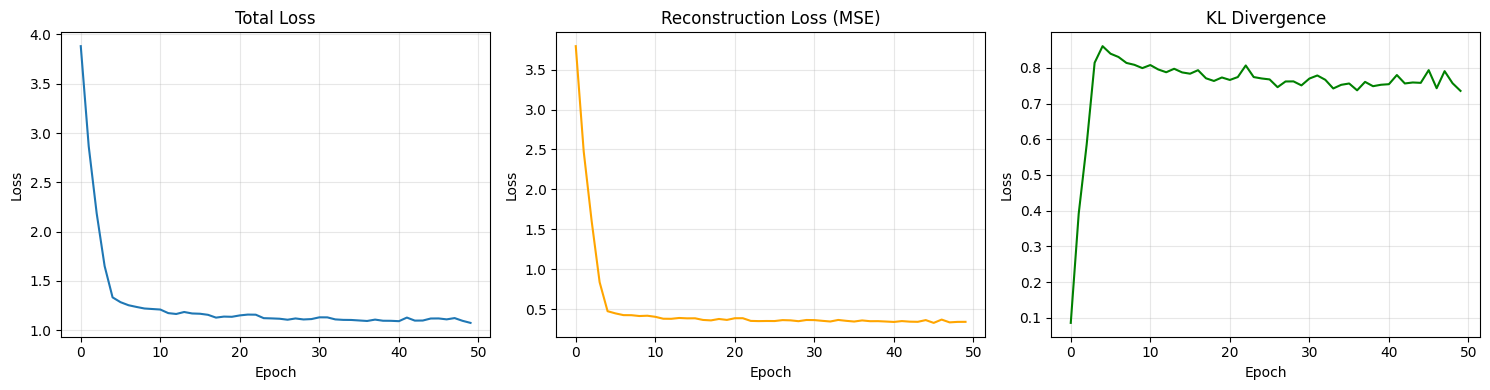

In [10]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(train_losses, label='Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Total Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(recon_losses, label='Reconstruction Loss', color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Reconstruction Loss (MSE)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(kl_losses, label='KL Divergence', color='green')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].set_title('KL Divergence')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Part 5b: Reconstruct data

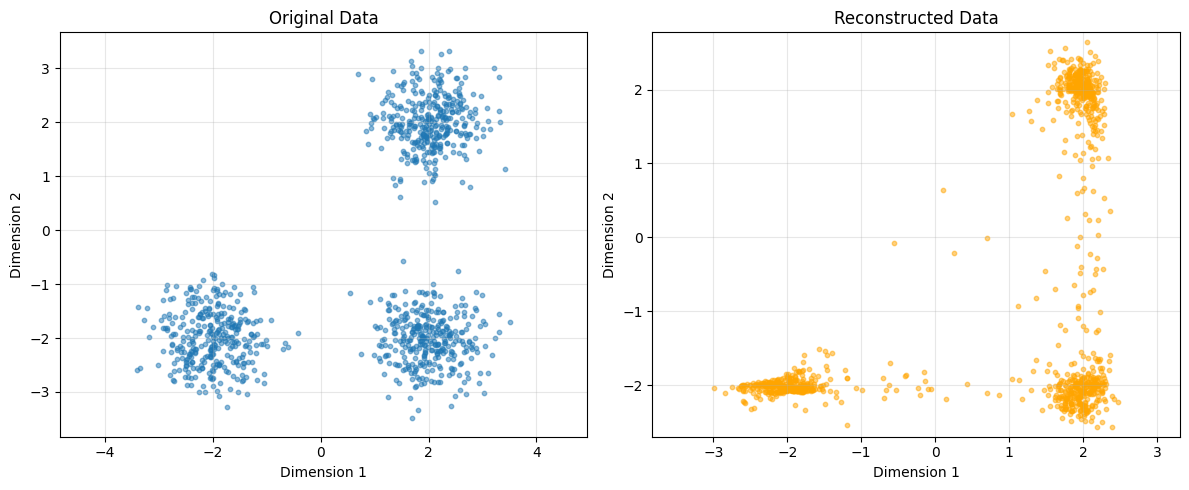

In [11]:
# Get reconstructions
model.eval()
with torch.no_grad():
    x_sample = data[:1000].to(device)
    x_recon, _, _, _ = model(x_sample)
    x_recon = x_recon.cpu()

# Plot original vs reconstructed
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(data[:1000, 0], data[:1000, 1], alpha=0.5, s=10)
axes[0].set_xlabel('Dimension 1')
axes[0].set_ylabel('Dimension 2')
axes[0].set_title('Original Data')
axes[0].grid(True, alpha=0.3)
axes[0].axis('equal')

axes[1].scatter(x_recon[:, 0], x_recon[:, 1], alpha=0.5, s=10, color='orange')
axes[1].set_xlabel('Dimension 1')
axes[1].set_ylabel('Dimension 2')
axes[1].set_title('Reconstructed Data')
axes[1].grid(True, alpha=0.3)
axes[1].axis('equal')

plt.tight_layout()
plt.show()

### Part 5c: Visualize latent space

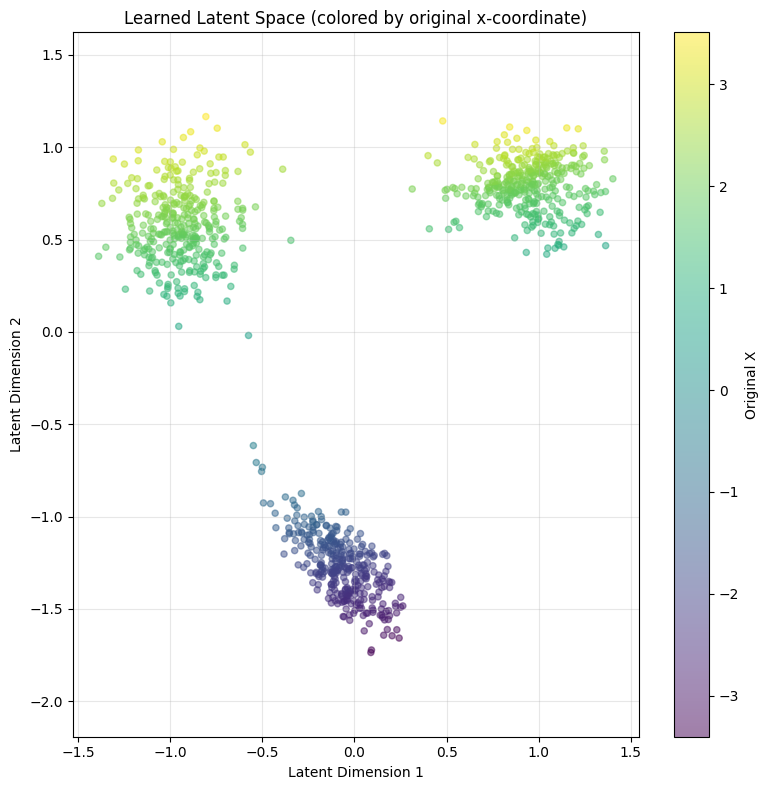

In [12]:
# Encode data to latent space
with torch.no_grad():
    x_sample = data[:1000].to(device)
    mu, _ = model.encoder(x_sample)
    mu = mu.cpu()

# Plot latent space
plt.figure(figsize=(8, 8))
plt.scatter(mu[:, 0], mu[:, 1], alpha=0.5, s=20, c=data[:1000, 0], cmap='viridis')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.title('Learned Latent Space (colored by original x-coordinate)')
plt.colorbar(label='Original X')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()

### Part 5d: Generate new samples

Sample from the prior p(z) = N(0, I) and decode to generate new data points.

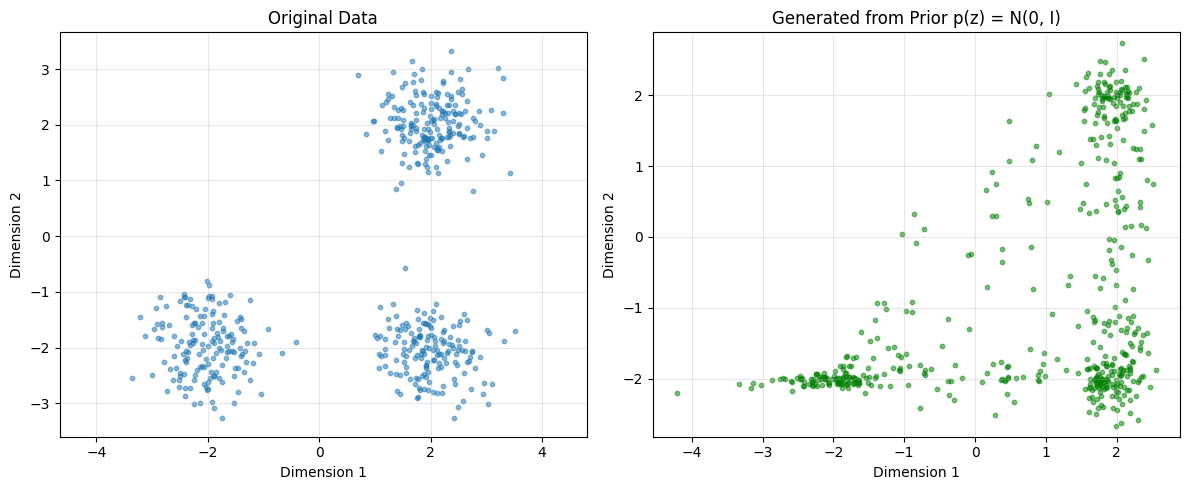

Original data range: x=[-3.36, 3.51], y=[-3.27, 3.33]
Generated data range: x=[-4.21, 2.56], y=[-2.67, 2.74]


In [13]:
# Generate new samples from prior
with torch.no_grad():
    z_samples = torch.randn(500, 2).to(device)  # Sample from N(0, I)
    x_generated = model.decoder(z_samples)
    x_generated = x_generated.cpu()

# Plot generated samples
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(data[:500, 0], data[:500, 1], alpha=0.5, s=10, label='Original')
axes[0].set_xlabel('Dimension 1')
axes[0].set_ylabel('Dimension 2')
axes[0].set_title('Original Data')
axes[0].grid(True, alpha=0.3)
axes[0].axis('equal')

axes[1].scatter(x_generated[:, 0], x_generated[:, 1], alpha=0.5, s=10, color='green', label='Generated')
axes[1].set_xlabel('Dimension 1')
axes[1].set_ylabel('Dimension 2')
axes[1].set_title('Generated from Prior p(z) = N(0, I)')
axes[1].grid(True, alpha=0.3)
axes[1].axis('equal')

plt.tight_layout()
plt.show()

print(f"Original data range: x=[{data[:500, 0].min():.2f}, {data[:500, 0].max():.2f}], y=[{data[:500, 1].min():.2f}, {data[:500, 1].max():.2f}]")
print(f"Generated data range: x=[{x_generated[:, 0].min():.2f}, {x_generated[:, 0].max():.2f}], y=[{x_generated[:, 1].min():.2f}, {x_generated[:, 1].max():.2f}]")

## Summary

In this notebook, we implemented a **Standard VAE** with the following key components:

1. **Encoder**: Maps data x → latent distribution q(z|x)
2. **Reparameterization trick**: Enables backpropagation through sampling
3. **Decoder**: Maps latent z → reconstructed data
4. **ELBO loss**: Balances reconstruction and KL regularization
5. **Generation**: Can sample from prior p(z) to generate new data

## Next Steps

In the later LFADS notebooks (`06_lfads.ipynb` and `07_FULL_LFADS_Tutorial.ipynb`), we'll extend this to **Sequential VAE (LFADS)** by:
- Adding **recurrent encoders/decoders** for time-series data
- Modeling **dynamics** in the latent space
- Inferring **external inputs** driving the dynamics
- Applying to **neural spike train data**